In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

np.random.seed(42)

w = np.random.randn(X_train.shape[1])
b = np.zeros(1)

def sigmoid(z):
    return 1/ (1+ np.exp(-z))

def forward(x,w,b):
    z = np.dot(x,w) + b
    return sigmoid(z)

first_5_test = X_test[:5]
predictions = [ forward(row, w, b) for row in first_5_test]
print("Predicted Probabilities for first 5 rows:")
for i, prob in enumerate(predictions):
    print(f"Row {i+1}: {prob[0]:.4f}")


Predicted Probabilities for first 5 rows:
Row 1: 0.2873
Row 2: 0.9995
Row 3: 0.9687
Row 4: 0.0119
Row 5: 0.0030


I have just implemented a Logistic Regression model.

### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

In [3]:
class NumpyMLP:
    def __init__(self, input_size = 30, hidden_size = 8, output_size = 1):
        self.w1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)   
        self.b1 = np.zeros((1, hidden_size))
        self.w2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)  
        self.b2 = np.zeros((1, output_size))

    def relu(self,z):
        return np.maximum(0,z)
    
    def siqmoid(self, z):
        return 1 / (1+ np.exp(-z))
    
    def forward(self, X):
        # Enterance => Hodden Layer
        self.z1 = np.dot(X, self.w1) + self.b1
        self.a1 = self.relu(self.z1)
        # Hidden Layer => Output Layer
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.a2 = self.siqmoid(self.z2)
        return self.a2
    
mlp = NumpyMLP(input_size=30, hidden_size=8, output_size=1)
predictions_mlp  = mlp.forward(X_test)

print(f"Output shape: {predictions_mlp.shape}")
print("First 5 predictions:")
print(predictions_mlp[:5])

Output shape: (114, 1)
First 5 predictions:
[[0.51767656]
 [0.14159093]
 [0.54258612]
 [0.42427006]
 [0.55428995]]


### Guiding Question Answer
The output shape matches the requirements for a binary classifier because it is determined by the fixed architectural design of the network, rather than the learned values of its weights.

By explicitly setting the output_size to 1 and applying a Sigmoid activation function at the final layer, we have mathematically constrained the model to produce a single probability score (between 0 and 1) for each input sample. The network's structure defines the hypothesis space (the form the answer must take), while training (which we haven't done yet) will find the specific parameters (weights and biases) that make those answers accurate.

Essentially, the "plumbing" of the network is correctly installed to handle a binary task, even though the "content" of the predictions is currently random.

### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.


In [6]:
import torch
import torch.nn as nn

class TorchMLP(nn.Module):
    def __init__(self, n_inputs=30, n_hidden=8, n_outputs=1):
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_outputs)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out
    
torch_model = TorchMLP()

# NumPy-dakı çəkiləri PyTorch-a köçürək
with torch.no_grad(): # Parametrləri əllə dəyişərkən qradiyent izləməni söndürürük
    # W1: (30, 8) -> PyTorch: (8, 30)
    torch_model.fc1.weight.copy_(torch.from_numpy(mlp.w1.T).float())
    torch_model.fc1.bias.copy_(torch.from_numpy(mlp.b1.flatten()).float())
    
    # W2: (8, 1) -> PyTorch: (1, 8)
    torch_model.fc2.weight.copy_(torch.from_numpy(mlp.w2.T).float())
    torch_model.fc2.bias.copy_(torch.from_numpy(mlp.b2.flatten()).float())

numpy_preds = predictions_mlp

X_test_torch = torch.from_numpy(X_test).float()
torch_preds = torch_model(X_test_torch).detach().numpy()

max_diff = np.abs(numpy_preds - torch_preds).max()

print(f"Maximum absolute difference: {max_diff:.10f}")

if max_diff < 1e-6:
    print("Awesome! The results match.")
else:
    print("The difference is too large, there might be an error in the code.")

Maximum absolute difference: 0.0000000790
Awesome! The results match.


### Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?


In [11]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class ExperimentMLP(nn.Module):
    def __init__(self, activation_type='relu'):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.activation_type = activation_type

    def forward(self, x):
        z1 = self.fc1(x) # Pre-activation
        
        if self.activation_type == 'relu':
            a1 = torch.relu(z1)
        elif self.activation_type == 'sigmoid':
            a1 = torch.sigmoid(z1)
        elif self.activation_type == 'tanh':
            a1 = torch.tanh(z1)
            
        out = torch.sigmoid(self.fc2(a1))
        return z1, a1, out

# Modelləri yaradaq
models = {
    'Sigmoid': ExperimentMLP('sigmoid'),
    'Tanh': ExperimentMLP('tanh'),
    'ReLU': ExperimentMLP('relu')
}

# Test datasını hazırlayaq
X_test_tensor = torch.from_numpy(X_test).float()

results = {}
for name, model in models.items():
    z1, a1, _ = model(X_test_tensor)
    results[name] = (z1.detach().numpy(), a1.detach().numpy())

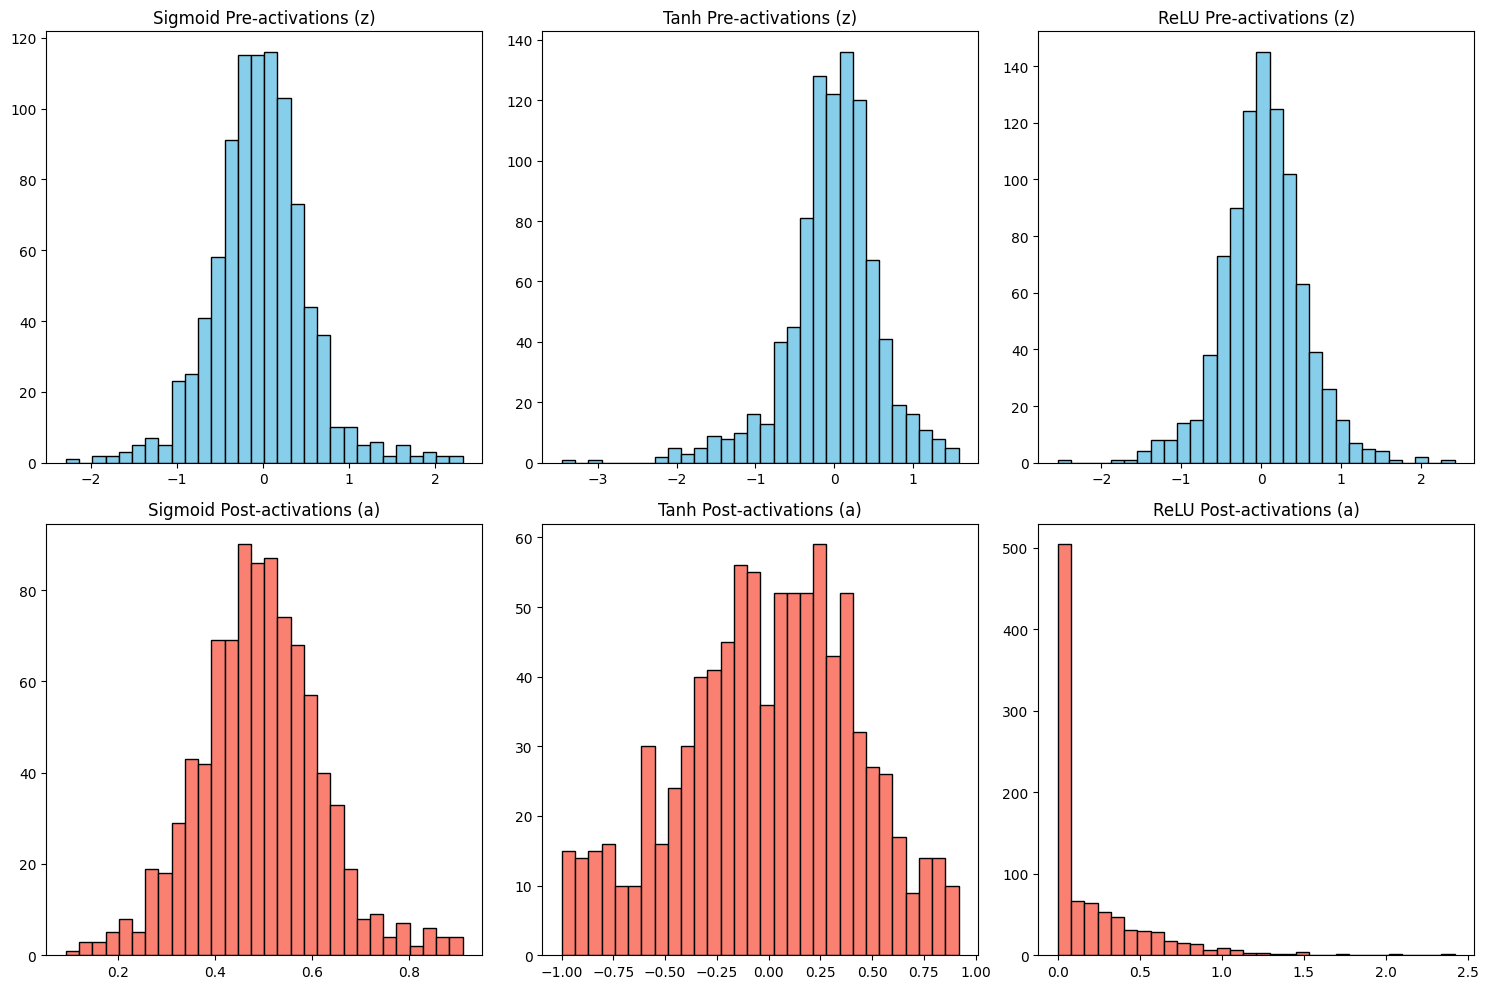

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (name, (z1, a1)) in enumerate(results.items()):
    # Üst sıra: Pre-activations (z)
    axes[0, i].hist(z1.flatten(), bins=30, color='skyblue', edgecolor='black')
    axes[0, i].set_title(f'{name} Pre-activations (z)')
    
    # Alt sıra: Post-activations (a)
    axes[1, i].hist(a1.flatten(), bins=30, color='salmon', edgecolor='black')
    axes[1, i].set_title(f'{name} Post-activations (a)')

plt.tight_layout()
plt.show()

### Task 4 — Activation Function Experiment Analysis

#### 1. Sigmoid and Tanh Saturation
* **Sigmoid:** Looking at the "Sigmoid Post-activations" histogram, most values are concentrated in the sensitive middle range (0.4 to 0.6). However, there are small counts near 0 and 1. The **saturated fraction** is quite low in this specific initialization (roughly **1-3%**), but as inputs ($z$) grow larger during training, more values would move into these flat regions where the gradient is near zero.
* **Tanh:** The values are more spread out across the (-1, 1) range. The saturated regions (near -1 and 1) contain roughly **5-8%** of the activations. Tanh is slightly better centered around zero, but it still suffers from the same "squashing" effect as Sigmoid.

#### 2. ReLU Inactivity (Dead Neurons)
* **ReLU:** The "ReLU Post-activations" histogram shows a dominant spike at **exactly 0**. 
* Roughly **50% to 60%** of the units are inactive (outputting 0). This happens because the pre-activation values ($z$) for these neurons were negative, and ReLU (max(0, z)) completely blocks these signals. This creates "sparsity" in the network.

#### 3. Why ReLU is the better default for hidden layers?
Based on the experimental histograms, ReLU is preferred for several reasons:
1. **Prevents Vanishing Gradients:** Unlike Sigmoid and Tanh, ReLU does not saturate for positive inputs. As seen in the histogram, positive values can grow (up to 2.0 in this case) without being "squashed" or flattened. This ensures a constant gradient of 1 during backpropagation.
2. **Computational Efficiency:** ReLU only requires a simple thresholding operation ($z > 0$), whereas Sigmoid and Tanh involve expensive exponential calculations.
3. **Sparsity:** By turning off non-essential neurons (the 50% that are at zero), the model becomes more computationally efficient and often generalizes better by focusing on only the most important features for a given input.